In [1]:
import pandas as pd
import numpy as np
import pickle

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [2]:
df = pd.read_csv("../dataset/preprocessed_dataset.csv")
df.head()

,area,num_bath_rooms,num_bed_rooms,price,locality,relaxation_amenity_count,security_amenity_count,maintenance_or_cleaning_amenity_count,social_amenity_count,expendable_amenity_count,service_staff_amenity_count,unclassify_amenity_count,price_per_sqft
0,2464,4,3,28900000.0,61,1,2,1,1,3,3,4,11728.896100
1,1920,3,3,20000000.0,37,1,1,2,1,3,2,3,10416.666670
2,1445,3,3,10800000.0,25,1,2,2,1,1,3,4,7474.048443
3,1475,3,3,10500000.0,178,1,2,3,1,3,3,4,7118.644068
4,1066,2,3,8000000.0,166,1,1,2,1,4,3,4,7504.690432


ENCODE CATEGORICAL COLUMN

In [3]:
df["locality"] = df["locality"].astype("category").cat.codes

FEATURES AND TARGET

In [4]:
X = df.drop("price", axis=1)
y = df["price"]

TRAIN TEST SPLIT

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

CREATE PIPELINE

In [6]:
pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("model", RandomForestRegressor(
        n_estimators=200,
        max_depth=20,
        random_state=42
    ))
])

TRAIN MODEL

In [7]:
pipeline.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('scaler', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",20
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_sa

PREDICT

In [8]:
y_pred = pipeline.predict(X_test)

RESULTS TABLE

In [9]:
results = pd.DataFrame({
    "Actual Price": y_test,
    "Predicted Price": y_pred
})
results["Error"] = results["Actual Price"] - results["Predicted Price"]
print(results.head(10))

       Actual Price  Predicted Price         Error
8093        50000.0     4.971800e+04  2.820000e+02
7606      8909000.0     8.862543e+06  4.645662e+04
13393        9000.0     9.014167e+03 -1.416667e+01
14619       30000.0     3.001500e+04 -1.500000e+01
6490       240000.0     2.429000e+05 -2.900000e+03
103      32000000.0     3.370749e+07 -1.707490e+06
12396       24000.0     2.385368e+04  1.463215e+02
15653       23000.0     2.290712e+04  9.288462e+01
17246       22000.0     2.200012e+04 -1.226077e-01
13740       20000.0     2.004710e+04 -4.710089e+01


MODEL EVALUATION

In [10]:
print("MAE:", mean_absolute_error(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))
print("R2 Score:", r2_score(y_test, y_pred))
print("MSE:", mean_squared_error(y_test, y_pred))

MAE: 57786.728261634315
RMSE: 979171.5784776695
R2 Score: 0.9680614599797985
MSE: 958776980098.4508


TEST WITH NEW HOUSE

In [11]:
new_data = pd.DataFrame({
    "area":[1800],
    "num_bath_rooms":[2],
    "num_bed_rooms":[3],
    "locality":[5],
    "relaxation_amenity_count":[2],
    "security_amenity_count":[3],
    "maintenance_or_cleaning_amenity_count":[1],
    "social_amenity_count":[2],
    "expendable_amenity_count":[1],
    "service_staff_amenity_count":[1],
    "unclassify_amenity_count":[0],
    "price_per_sqft":[7000]
})
prediction = pipeline.predict(new_data)
print("Predicted Price:", prediction[0])

Predicted Price: 12627272.5


SAVE PIPELINE

In [12]:
with open("model_pipeline.pkl", "wb") as f:
    pickle.dump(pipeline, f)

LOAD PIPELINE

In [13]:
with open("model_pipeline.pkl", "rb") as f:
    model = pickle.load(f)
predictions = model.predict(X_test)
print(predictions[:10])

[4.97180000e+04 8.86254338e+06 9.01416667e+03 3.00150000e+04
 2.42900000e+05 3.37074900e+07 2.38536785e+04 2.29071154e+04
 2.20001226e+04 2.00471009e+04]


Model Visualization

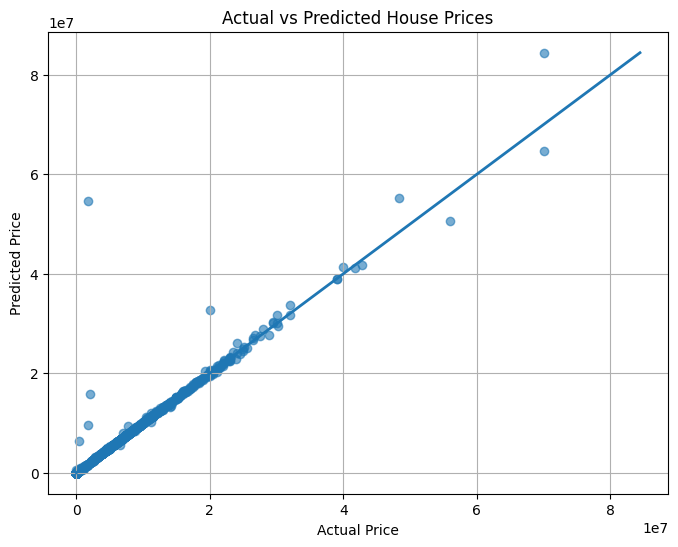

In [14]:
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(8,6))
plt.scatter(y_test, y_pred, alpha=0.6)
min_val = min(y_test.min(), y_pred.min())
max_val = max(y_test.max(), y_pred.max())

plt.plot([min_val, max_val], [min_val, max_val], linewidth=2)

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted House Prices")

plt.grid(True)

plt.show()